In [1]:
import pathlib
from geoband import API
import geopandas as  gpd
import pandas as pd
import os
from shapely.geometry import Point
import json
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

# 공모전 제공 데이터 전처리

In [2]:
input_path = pathlib.Path('./data')
if not input_path.is_dir():
    input_path.mkdir()

API.GetCompasData('SBJ_2601_001', '20', input_path.joinpath( '01._격자_(4개_시·구).geojson'))
API.GetCompasData('SBJ_2601_001', '21', input_path.joinpath( '02._격자_(하남교산).geojson'))
API.GetCompasData('SBJ_2601_001', '3', input_path.joinpath(  '03._성연령별_거주인구(격자).csv'))
API.GetCompasData('SBJ_2601_001', '4', input_path.joinpath( '04._성연령별_유동인구.csv'))
API.GetCompasData('SBJ_2601_001', '5', input_path.joinpath( '05._시간대별_직장인구.csv'))
API.GetCompasData('SBJ_2601_001', '6', input_path.joinpath('06._시간대별_방문인구.csv'))
API.GetCompasData('SBJ_2601_001', '7', input_path.joinpath(  '07._주중주말_서비스인구.csv'))
API.GetCompasData('SBJ_2601_001', '24', input_path.joinpath( '08.상세도로망_네트워크.geojson'))
API.GetCompasData('SBJ_2601_001', '25', input_path.joinpath( '09._평균속도.csv'))
API.GetCompasData('SBJ_2601_001', '26', input_path.joinpath( '10._추정교통량.csv'))
API.GetCompasData('SBJ_2601_001', '27', input_path.joinpath( '11._혼잡빈도강도.csv'))
API.GetCompasData('SBJ_2601_001', '28', input_path.joinpath( '12._혼잡시간강도.csv'))
API.GetCompasData('SBJ_2601_001', '8', input_path.joinpath( '13._교통사고이력.geojson'))
API.GetCompasData('SBJ_2601_001', '9', input_path.joinpath(  '14._어린이보호구역.csv'))
API.GetCompasData('SBJ_2601_001', '10', input_path.joinpath(  '15._학교현황.csv'))
API.GetCompasData('SBJ_2601_001', '11', input_path.joinpath('16._유치원현황.csv'))
API.GetCompasData('SBJ_2601_001', '12', input_path.joinpath( '17._어린이집현황.csv'))
API.GetCompasData('SBJ_2601_001', '13', input_path.joinpath( '18._횡단보도_위치정보.csv'))
API.GetCompasData('SBJ_2601_001', '14', input_path.joinpath(  '19._버스정류장_위치정보.csv'))
API.GetCompasData('SBJ_2601_001', '15', input_path.joinpath( '20._CCTV_현황.csv'))
API.GetCompasData('SBJ_2601_001', '16', input_path.joinpath(  '21._과속방지턱_현황.csv'))
API.GetCompasData('SBJ_2601_001', '22', input_path.joinpath(  '22._토지이용계획도_(4개_신도시).geojson'))
API.GetCompasData('SBJ_2601_001', '23', input_path.joinpath( '23._토지이용계획도_(하남교산).geojson'))
API.GetCompasData('SBJ_2601_001', '29', input_path.joinpath(  '25._교통데이터_코드표.csv'))
print('완료')


[2026-03-19 07:56:38] 성공 - data/01._격자_(4개_시·구).geojson
[2026-03-19 07:56:38] 성공 - data/02._격자_(하남교산).geojson
[2026-03-19 07:56:38] 성공 - data/03._성연령별_거주인구(격자).csv
[2026-03-19 07:56:48] 성공 - data/04._성연령별_유동인구.csv
[2026-03-19 07:57:06] 성공 - data/05._시간대별_직장인구.csv
[2026-03-19 07:57:24] 성공 - data/06._시간대별_방문인구.csv
[2026-03-19 07:57:36] 성공 - data/07._주중주말_서비스인구.csv
[2026-03-19 07:57:36] 성공 - data/08.상세도로망_네트워크.geojson
[2026-03-19 07:57:38] 성공 - data/09._평균속도.csv
[2026-03-19 07:57:40] 성공 - data/10._추정교통량.csv
[2026-03-19 07:57:40] 성공 - data/11._혼잡빈도강도.csv
[2026-03-19 07:57:40] 성공 - data/12._혼잡시간강도.csv
[2026-03-19 07:57:40] 성공 - data/13._교통사고이력.geojson
[2026-03-19 07:57:40] 성공 - data/14._어린이보호구역.csv
[2026-03-19 07:57:40] 성공 - data/15._학교현황.csv
[2026-03-19 07:57:40] 성공 - data/16._유치원현황.csv
[2026-03-19 07:57:40] 성공 - data/17._어린이집현황.csv
[2026-03-19 07:57:40] 성공 - data/18._횡단보도_위치정보.csv
[2026-03-19 07:57:40] 성공 - data/19._버스정류장_위치정보.csv
[2026-03-19 07:57:40] 성공 - data/20._CCTV_현황.csv
[2026-03-1

In [3]:
## 데이터 로드 & 확인

def load_file(file_path, show_info=True, show_null=True, show_head=True):
    """
    파일을 로드하고 데이터의 기본 정보, 결측치 현황, 상위 행을 출력합니다.
    """
    ext = os.path.splitext(file_path)[-1].lower()
    
    # 파일 로드
    if ext == '.csv':
        df = pd.read_csv(file_path)
    elif ext in ['.geojson', '.json']:
        df = gpd.read_file(file_path)
    else:
        raise ValueError(f"지원하지 않는 파일 형식입니다: {ext}")

    # 정보 출력
    print(f"\n{'='*50}")
    print(f"[FILE PATH]: {file_path}")
    print(f"{'='*50}")

    if show_info:
        print(f'\n[1. INFO]')
        df.info()
        if ext in ['.geojson', '.json']:
            print(f'Geometry type: {df.geometry.geom_type.unique()}')

    if show_null:
        print(f'\n[2. MISSING VALUES (isnull().sum())]')
        null_counts = df.isnull().sum()
        print(null_counts[null_counts > 0] if (null_counts > 0).any() else "결측치 없음")

    if show_head:
        print(f'\n[3. HEAD (First 5 rows)]')
        display(df.head())
        
    return df

# 격자        
grid = load_file(input_path.joinpath('01._격자_(4개_시·구).geojson'))
grid_hanam = load_file(input_path.joinpath('02._격자_(하남교산).geojson'))
future_all = load_file(input_path.joinpath('22._토지이용계획도_(4개_신도시).geojson'))
future_hanam = load_file(input_path.joinpath('23._토지이용계획도_(하남교산).geojson'))

# 인구
resident = load_file(input_path.joinpath('03._성연령별_거주인구(격자).csv'))
floating = load_file(input_path.joinpath('04._성연령별_유동인구.csv'))
work = load_file(input_path.joinpath('05._시간대별_직장인구.csv'))
visit = load_file(input_path.joinpath('06._시간대별_방문인구.csv'))
service = load_file(input_path.joinpath('07._주중주말_서비스인구.csv'))

# 교통
roads = load_file(input_path.joinpath('08.상세도로망_네트워크.geojson'))
speed = load_file(input_path.joinpath('09._평균속도.csv'))
volume = load_file(input_path.joinpath('10._추정교통량.csv'))
code = load_file(input_path.joinpath('25._교통데이터_코드표.csv'))
freq_intensity = load_file(input_path.joinpath('11._혼잡빈도강도.csv'))
time_intensity = load_file(input_path.joinpath('12._혼잡시간강도.csv'))

# 사고
accident = load_file(input_path.joinpath('13._교통사고이력.geojson'))

# 시설 & 시설물
zone = load_file(input_path.joinpath('14._어린이보호구역.csv'))
school = load_file(input_path.joinpath('15._학교현황.csv'))
kinder = load_file(input_path.joinpath('16._유치원현황.csv'))
nursery = load_file(input_path.joinpath('17._어린이집현황.csv'))
crosswalk = load_file(input_path.joinpath('18._횡단보도_위치정보.csv'))
bus = load_file(input_path.joinpath('19._버스정류장_위치정보.csv'))
cctv = load_file(input_path.joinpath('20._CCTV_현황.csv'))
bump = load_file(input_path.joinpath('21._과속방지턱_현황.csv'))


[FILE PATH]: data/01._격자_(4개_시·구).geojson

[1. INFO]
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 99323 entries, 0 to 99322
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   std_yr    99323 non-null  int64   
 1   gbn       99323 non-null  object  
 2   gid       99323 non-null  object  
 3   geometry  99323 non-null  geometry
dtypes: geometry(1), int64(1), object(2)
memory usage: 3.0+ MB
Geometry type: ['Polygon']

[2. MISSING VALUES (isnull().sum())]
결측치 없음

[3. HEAD (First 5 rows)]


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,2024,경기도 성남시,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,2024,경기도 성남시,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,2024,경기도 성남시,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."



[FILE PATH]: data/02._격자_(하남교산).geojson

[1. INFO]
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   gbn       770 non-null    object  
 1   gid       770 non-null    object  
 2   geometry  770 non-null    geometry
dtypes: geometry(1), object(2)
memory usage: 18.2+ KB
Geometry type: ['Polygon']

[2. MISSING VALUES (isnull().sum())]
결측치 없음

[3. HEAD (First 5 rows)]


,gbn,gid,geometry
0,경기도 하남시,다사720443,"POLYGON ((127.18323 37.49754, 127.18323 37.498..."
1,경기도 하남시,다사720444,"POLYGON ((127.18323 37.49844, 127.18323 37.499..."
2,경기도 하남시,다사721443,"POLYGON ((127.18436 37.49754, 127.18436 37.498..."
3,경기도 하남시,다사721444,"POLYGON ((127.18436 37.49844, 127.18436 37.499..."
4,경기도 하남시,다사721445,"POLYGON ((127.18436 37.49934, 127.18435 37.500..."



[FILE PATH]: data/22._토지이용계획도_(4개_신도시).geojson

[1. INFO]
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5337 entries, 0 to 5336
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   zoneCode   5337 non-null   object  
 1   zoneName   5337 non-null   object  
 2   blockName  5337 non-null   object  
 3   blockType  5337 non-null   object  
 4   geometry   5337 non-null   geometry
dtypes: geometry(1), object(4)
memory usage: 208.6+ KB
Geometry type: ['Polygon']

[2. MISSING VALUES (isnull().sum())]
결측치 없음

[3. HEAD (First 5 rows)]


...

,bis_id,stn_nm,lon,lat
0,GGB233001415,양지말입구,126.715767,37.205283
1,GGB233001416,주곡1리입구,126.818817,37.116483
2,GGB233001417,주곡2리(회차),126.804433,37.114267
3,GGB233001418,장안9리입구,126.854583,37.060633
4,GGB233001419,장안6리,126.856350,37.052367



[FILE PATH]: data/20._CCTV_현황.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28347 entries, 0 to 28346
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   inst_purp  28347 non-null  object 
 1   cam_cnt    28347 non-null  int64  
 2   inst_ym    18573 non-null  object 
 3   lon        28347 non-null  float64
 4   lat        28347 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.1+ MB

[2. MISSING VALUES (isnull().sum())]
inst_ym    9774
dtype: int64

[3. HEAD (First 5 rows)]


,inst_purp,cam_cnt,inst_ym,lon,lat
0,생활방범,1,NaN,127.187070,37.554350
1,생활방범,1,201601,127.158415,37.491628
2,교통단속,3,201812,127.178900,37.573660
3,생활방범,3,NaN,127.145104,37.504200
4,생활방범,4,202206,127.210744,37.548145



[FILE PATH]: data/21._과속방지턱_현황.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4397 entries, 0 to 4396
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gbn       4397 non-null   object 
 1   addr      4397 non-null   object 
 2   inst_plc  4396 non-null   object 
 3   fac_hght  2385 non-null   float64
 4   fac_wdth  4396 non-null   float64
 5   sprtn     2770 non-null   object 
 6   cntns     2770 non-null   object 
 7   lon       4397 non-null   float64
 8   lat       4397 non-null   float64
dtypes: float64(4), object(5)
memory usage: 309.3+ KB

[2. MISSING VALUES (isnull().sum())]
inst_plc       1
fac_hght    2012
fac_wdth       1
sprtn       1627
cntns       1627
dtype: int64

[3. HEAD (First 5 rows)]


,gbn,addr,inst_plc,fac_hght,fac_wdth,sprtn,cntns,lon,lat
0,경기도 화성시,경기도 화성시 향남읍 하길리 1473번지 서봉마을모아엘가,도시계획도로,7.5,3.6,N,N,126.912640,37.112718
1,경기도 화성시,경기도 화성시 양감면 용소리 845-3번지,도시계획도로,7.5,3.6,N,N,126.975853,37.079725
2,경기도 화성시,경기도 화성시 우정읍 이화리 1192-5,도시계획도로,7.5,3.6,N,N,126.788973,37.042843
3,경기도 화성시,경기도 화성시 우정읍 이화리 538,도시계획도로,7.5,3.6,N,N,126.790167,37.041710
4,경기도 화성시,경기도 화성시 장안면 독정리 1247,도시계획도로,7.5,3.6,N,N,126.870859,37.076428


### - 격자별 데이터 생성

In [4]:
# 인구, 시설데이터

def make_gid_agg(df, grid, agg_dict, output_name, lon_col='lon', lat_col='lat'):
    target_crs = 'EPSG:5179'
    grid_proj = grid.to_crs(target_crs)

    if 'gid' in df.columns:
        print(f"> {output_name}: 기존 'gid' 컬럼 사용")
        gdf_with_gid = df.copy()
    else:
        print(f"> {output_name}: 위경도 기반 공간 조인 수행")
        gdf = gpd.GeoDataFrame(
            df.copy(),
            geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
            crs='EPSG:4326'
        ).to_crs(target_crs)
        gdf_with_gid = gpd.sjoin(gdf, grid_proj[['gid', 'geometry']], how='left', predicate='within')

    # agg_dict 정규화
    final_named_agg = {}
    for new_col, action in agg_dict.items():
        if isinstance(action, tuple):
            final_named_agg[new_col] = action
        else:
            final_named_agg[new_col] = (new_col, action)
            
    # 자동 컬럼 보존
    used_origin_cols = [v[0] for v in final_named_agg.values()]
    exclude_cols = ['gid', lon_col, lat_col, 'geometry', 'index_right'] + used_origin_cols
    for col in df.columns:
        if col not in final_named_agg and col not in exclude_cols:
            final_named_agg[col] = (col, 'first')

    # 격자 단위 집계
    agg_df = gdf_with_gid.groupby('gid').agg(**final_named_agg).reset_index()
    final_agg_df = pd.merge(grid, agg_df, on='gid', how='left').fillna(0)

    # 위경도 좌표 추출
    temp_gdf = gpd.GeoDataFrame(final_agg_df, geometry='geometry', crs=grid.crs)
    centroids_4326 = temp_gdf.to_crs(target_crs).geometry.centroid.to_crs('EPSG:4326')
    final_agg_df['lon'] = centroids_4326.x
    final_agg_df['lat'] = centroids_4326.y

    # 저장
    save_path = f"{output_name}"
    save_df = pd.DataFrame(final_agg_df).drop(columns=['geometry'])
    save_df.to_csv(save_path, index=False, encoding='utf-8-sig')
    return final_agg_df




# --- 인구 및 시설 데이터 격자 집계 수행 ---

# 인구
# resident
r_cols = ['m_20g_pop', 'm_30g_pop', 'm_40g_pop', 'm_50g_pop', 'm_60g_pop', 'm_70g_pop', 'm_80g_pop', 'm_90g_pop', 'm_100g_pop',
          'w_20g_pop', 'w_30g_pop', 'w_40g_pop', 'w_50g_pop', 'w_60g_pop','w_70g_pop', 'w_80g_pop', 'w_90g_pop', 'w_100g_pop']
resident['resident_total_pop'] = resident[r_cols].sum(axis=1)
resident['resident_senior_pop'] = resident[['m_60g_pop', 'm_70g_pop', 'm_80g_pop', 'm_90g_pop', 'm_100g_pop',
                                           'w_60g_pop', 'w_70g_pop', 'w_80g_pop', 'w_90g_pop', 'w_100g_pop']].sum(axis=1)

grid_resident = make_gid_agg(resident,grid,agg_dict={'resident_total_pop': 'sum', 'resident_senior_pop': 'sum'},output_name='grid_resident.csv')

# floating
pop_cols_f = ['m_10g_pop','m_20g_pop','m_30g_pop','m_40g_pop','m_50g_pop','m_60g_pop',
              'w_10g_pop','w_20g_pop','w_30g_pop','w_40g_pop','w_50g_pop','w_60g_pop']
floating['floating_total_pop'] = floating[pop_cols_f].sum(axis=1)
floating['floating_senior_pop'] = floating['m_60g_pop'] + floating['w_60g_pop']

grid_floating = make_gid_agg(floating,grid,agg_dict={'avg_floating_pop': ('floating_total_pop','mean'), 'avg_floating_senior': ('floating_senior_pop','mean'), 'floating_pt_cnt': ('floating_total_pop','count')}, output_name ='grid_floating.csv')

# work
tmst_cols = [f'TMST_{i:02d}' for i in range(24)]
work['total_pop'] = work[tmst_cols].sum(axis=1)
grid_work = make_gid_agg(work,grid,agg_dict={'avg_work_pop': ('total_pop','mean'),'work_pt_cnt': ('total_pop','count')},output_name ='grid_work.csv')

# visit
visit['total_pop'] = visit[tmst_cols].sum(axis=1)
grid_visit = make_gid_agg(visit,grid,agg_dict={'avg_visit_pop': ('total_pop','mean'),'visit_pt_cnt': ('total_pop','count')},output_name ='grid_visit.csv')


# service
service['total_pop'] = service['w_pop'] + service['v_pop']
grid_service = make_gid_agg(service,grid,agg_dict={'avg_service_pop': ('total_pop','sum'),'service_pt_cnt': ('total_pop','count')},output_name ='grid_service.csv')

# 시설
# school(elem)
elem_only = school[school['school_gbn'] == '초등학교'].copy()
grid_school = make_gid_agg(elem_only,grid,agg_dict={'cnt_school': ('school_nm', 'count')},output_name='grid_school.csv')

# kinder
grid_kinder = make_gid_agg(kinder,grid,agg_dict={'cnt_kinder': ('kinder_nm', 'count'), 'total_kinder_cap': ('appr_cap', 'sum')},output_name='grid_kinder.csv')

# nursery
nursery_active = nursery[nursery['oper_stat'].isin(['정상', '재개'])].copy()
grid_nursery = make_gid_agg(nursery_active,grid,agg_dict={'cnt_nursery': ('cc_name', 'count'),'total_nursery_cap': ('curr_cnt', 'sum') },output_name='grid_nursery.csv')


> grid_resident.csv: 기존 'gid' 컬럼 사용
> grid_floating.csv: 위경도 기반 공간 조인 수행
> grid_work.csv: 위경도 기반 공간 조인 수행
> grid_visit.csv: 위경도 기반 공간 조인 수행
> grid_service.csv: 위경도 기반 공간 조인 수행
> grid_school.csv: 위경도 기반 공간 조인 수행
> grid_kinder.csv: 위경도 기반 공간 조인 수행
> grid_nursery.csv: 위경도 기반 공간 조인 수행


In [5]:
# 시설물데이터 
# GeoDataFrame으로 변환

def csv_to_gdf(df):
    geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

cctv_gdf = csv_to_gdf(cctv)
cross_gdf = csv_to_gdf(crosswalk)
bump_gdf = csv_to_gdf(bump)
zone_gdf = csv_to_gdf(zone)
bus_gdf = csv_to_gdf(bus)

# 격자별 count 집계
def count_in_grid(point_gdf, grid, col_name):
    """
    point    : 시설 GeoDataFrame
    grid     : 격자 GeoDataFrame (gid 포함)
    col_name : 결과 컬럼 이름
    """
    point_gdf = point_gdf.to_crs(grid.crs)

    joined = gpd.sjoin(
        point_gdf,
        grid[['gid','geometry']],
        how='left',
        predicate='within'
    )

    count = joined.groupby('gid').size().reset_index(name=col_name)
    return count

cctv_cnt = count_in_grid(cctv_gdf, grid, 'cctv_cnt')
cross_cnt = count_in_grid(cross_gdf, grid, 'cross_cnt')
bump_cnt = count_in_grid(bump_gdf, grid, 'bump_cnt')
bus_cnt = count_in_grid(bus_gdf, grid, 'bus_cnt')

# 보호구역 플래그
def make_zone_flag(zone_gdf, grid):

    if 'zone_flag' in grid.columns:
        grid = grid.drop(columns=['zone_flag'])

    zone_gdf = zone_gdf.to_crs(grid.crs)

    join = gpd.sjoin(
        grid[['gid','geometry']],
        zone_gdf[['geometry']],
        how='inner',
        predicate='intersects'
    )

    flag = join[['gid']].drop_duplicates()
    flag['zone_flag'] = 1

    grid = grid.merge(flag, on='gid', how='left')
    grid['zone_flag'] = grid['zone_flag'].fillna(0)

    return grid

grid_zone = make_zone_flag(zone_gdf, grid)


# grid에 병합
grid_facility = grid_zone.merge(cctv_cnt, on='gid', how='left')
grid_facility = grid_facility.merge(cross_cnt, on='gid', how='left')
grid_facility = grid_facility.merge(bump_cnt, on='gid', how='left')
grid_facility = grid_facility.merge(bus_cnt, on='gid', how='left')

# 결측 처리
for col in ['cctv_cnt','cross_cnt','bump_cnt','zone_flag']:
    grid_facility[col] = grid_facility[col].fillna(0)
    
# 저장
grid_facility.to_csv('grid_facility.csv', index=False, encoding='utf-8-sig')

In [7]:
# 교통 데이터

# 파일 내 있을지모르는 오류 전처리
def clean_columns(df):
    df.columns = [str(col).replace('\ufeff', '').strip() for col in df.columns]
    return df

speed = clean_columns(speed)
volume = clean_columns(volume)
freq_intensity = clean_columns(freq_intensity)
time_intensity = clean_columns(time_intensity)


# 데이터 통합
# 1. [속도 + 교통량] 통합
# 두 데이터 중 하나만 있어도 정보를 유지하기 위해 'outer'를 사용
traffic_merged = pd.merge(
    speed,
    volume[['v_link_id', 'timeslot', 'ALL_AADT', 'PSCR_AADT', 'BUS_AADT', 'FGCR_AADT']],
    on=['v_link_id', 'timeslot'],
    how='outer'
)

# 2. [혼잡 빈도/시간 강도] 추가
traffic_merged = pd.merge(traffic_merged, freq_intensity[['v_link_id', 'FRIN_CG']], on='v_link_id', how='left')
traffic_merged = pd.merge(traffic_merged, time_intensity[['v_link_id', 'TI_CG']], on='v_link_id', how='left')

# 3. 매핑을 위한 컬럼 정리
# v_link_id와 timeslot은 병합 키이므로 반드시 포함
cols_to_keep = [col for col in traffic_merged.columns if col not in ['road_rank', 'sido_id', 'sigungu_id', 'emd_id', 'k_length']]
traffic_merged_clean = traffic_merged[cols_to_keep]

# 4. 도로망(roads_gdf) 위치 정보와 최종 결합
# roads_gdf(도로 전체)를 기준으로 결합(left)
up_traffic = roads.merge(traffic_merged_clean, left_on='up_v_link', right_on='v_link_id', how='left')
up_traffic['direction'] = 'UP'

dw_traffic = roads.merge(traffic_merged_clean, left_on='dw_v_link', right_on='v_link_id', how='left')
dw_traffic['direction'] = 'DOWN'

# 공간 데이터(GeoDataFrame) 형태로 최종 복구
final_gdf = gpd.GeoDataFrame(
    pd.concat([up_traffic, dw_traffic], ignore_index=True),
    geometry='geometry',
    crs=roads.crs
)



# 격자데이터 생성

# 1. 좌표계 변환
final_gdf = final_gdf.to_crs(epsg=5179)
with open('./data/01._격자_(4개_시·구).geojson', 'r', encoding='utf-8') as f:
    grid_data = json.load(f)

grid_gdf = gpd.GeoDataFrame.from_features(grid_data['features'], crs='epsg:4326').to_crs(epsg=5179)
grid_gdf['grid_area'] = grid_gdf.geometry.area
unique_grid_gdf = grid_gdf.drop_duplicates(subset='gid').copy()

# 2. 공간 연산(오버레이)
unique_roads = final_gdf[['up_v_link', 'dw_v_link', 'geometry', 'length', 'max_speed']].drop_duplicates()
road_segments = gpd.overlay(unique_roads, unique_grid_gdf, how='intersection')
road_segments['seg_length'] = road_segments.geometry.length
road_segments_df = pd.DataFrame(road_segments.drop(columns='geometry'))

# 3. 데이터 매핑 및 수치 계산
merged = road_segments_df.merge(
    final_gdf[['up_v_link', 'dw_v_link', 'timeslot', 'velocity_AVRG', 'ALL_AADT', 'FRIN_CG', 'TI_CG']],
    on=['up_v_link', 'dw_v_link'],
    how='left'
)

# 수치 변환 (NaN 값 0 처리 포함)
merged['speed_reduction_rate'] = ((pd.to_numeric(merged['max_speed'], errors='coerce').replace(0,1) -
                                  pd.to_numeric(merged['velocity_AVRG'], errors='coerce').fillna(0)) /
                                 pd.to_numeric(merged['max_speed'], errors='coerce').replace(0,1)).clip(lower=0)

merged['val_speed_len'] = merged['speed_reduction_rate'] * merged['seg_length']
merged['val_congest_len'] = merged['FRIN_CG'].fillna(0) * merged['seg_length']
merged['val_traffic_contrib'] = merged['ALL_AADT'].fillna(0) * (merged['seg_length'] / merged['length'])

# 4. 격자별 합계 산출
grid_agg = merged.groupby(['gid', 'timeslot'])[['val_speed_len', 'val_congest_len', 'val_traffic_contrib', 'seg_length']].sum().reset_index()

# 5. 최종 지수 산출
area_map = unique_grid_gdf.set_index('gid')['grid_area'].to_dict()
grid_agg['w_speed_reduction'] = grid_agg['val_speed_len'] / grid_agg['seg_length']
grid_agg['w_congestion_intensity'] = grid_agg['val_congest_len'] / grid_agg['seg_length']
grid_agg['grid_area'] = grid_agg['gid'].map(area_map)
grid_agg['traffic_load'] = grid_agg['val_traffic_contrib'] / grid_agg['grid_area']

# 6.공간 정보 복구
final_grid_traffic_gdf = unique_grid_gdf[['gid', 'geometry']].merge(grid_agg, on='gid', how='left')

# 도로가 없어 계산되지 않은 격자(NaN)들은 0
fill_cols = ['w_speed_reduction', 'w_congestion_intensity', 'traffic_load', 'seg_length']
final_grid_traffic_gdf[fill_cols] = final_grid_traffic_gdf[fill_cols].fillna(0)

# 저장
final_grid_traffic_gdf.to_csv('grid_congestion.csv', index=False, encoding='utf-8-sig')

In [8]:
# 미래 데이터
join_all = gpd.sjoin(future_all, grid[['gid','geometry']], how='left', predicate='intersects')
join_all.to_csv('grid_future.csv', index=False, encoding='utf-8-sig')

join_hanam = gpd.sjoin(future_hanam, grid_hanam[['gid','geometry']], how='left', predicate='intersects')
join_hanam.drop(columns='geometry').to_csv('grid_future_hanam.csv', index=False, encoding='utf-8-sig')

# 사고 데이터
join_acc = gpd.sjoin(accident, grid[['gid','geometry']],how='left',predicate='within')
grid_accident = join_acc.drop(columns='geometry')
grid_accident.to_csv('grid_accident.csv', index=False, encoding='utf-8-sig')

In [9]:
## 격자 데이터 확인
categories = ['resident', 'floating', 'work', 'visit', 'service',
              'school','kinder','nursery','facility','congestion',
              'future','future_hanam','accident']

for cat in categories:
    globals()[f'grid_{cat}'] = load_file(f'grid_{cat}.csv')


[FILE PATH]: grid_resident.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99323 entries, 0 to 99322
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   std_yr               99323 non-null  int64  
 1   gbn_x                99323 non-null  object 
 2   gid                  99323 non-null  object 
 3   resident_total_pop   99323 non-null  float64
 4   resident_senior_pop  99323 non-null  float64
 5   gbn_y                99323 non-null  object 
 6   year                 99323 non-null  int64  
 7   m_20g_pop            99323 non-null  float64
 8   w_20g_pop            99323 non-null  float64
 9   m_30g_pop            99323 non-null  float64
 10  w_30g_pop            99323 non-null  float64
 11  m_40g_pop            99323 non-null  float64
 12  w_40g_pop            99323 non-null  float64
 13  m_50g_pop            99323 non-null  float64
 14  w_50g_pop            99323 non-null  float6

,std_yr,gbn_x,gid,resident_total_pop,resident_senior_pop,gbn_y,year,m_20g_pop,w_20g_pop,m_30g_pop,...,m_70g_pop,w_70g_pop,m_80g_pop,w_80g_pop,m_90g_pop,w_90g_pop,m_100g_pop,w_100g_pop,lon,lat
0,2024,경기도 성남시,다사581304,0.0,0.0,경기도 성남시,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027337,37.372175
1,2024,경기도 성남시,다사581305,0.0,0.0,경기도 성남시,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027331,37.373076
2,2024,경기도 성남시,다사581306,0.0,0.0,경기도 성남시,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027325,37.373978
3,2024,경기도 성남시,다사582304,0.0,0.0,경기도 성남시,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028466,37.372179
4,2024,경기도 성남시,다사582305,0.0,0.0,경기도 성남시,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028460,37.373081



[FILE PATH]: grid_floating.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99323 entries, 0 to 99322
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   std_yr               99323 non-null  int64  
 1   gbn_x                99323 non-null  object 
 2   gid                  99323 non-null  object 
 3   avg_floating_pop     99323 non-null  float64
 4   avg_floating_senior  99323 non-null  float64
 5   floating_pt_cnt      99323 non-null  float64
 6   gbn_y                99323 non-null  object 
 7   STD_YM               99323 non-null  float64
 8   m_10g_pop            99323 non-null  float64
 9   m_20g_pop            99323 non-null  float64
 10  m_30g_pop            99323 non-null  float64
 11  m_40g_pop            99323 non-null  float64
 12  m_50g_pop            99323 non-null  float64
 13  m_60g_pop            99323 non-null  float64
 14  w_10g_pop            99323 non-null  float6

,std_yr,gbn_x,gid,avg_floating_pop,avg_floating_senior,floating_pt_cnt,gbn_y,STD_YM,m_10g_pop,m_20g_pop,...,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat
0,2024,경기도 성남시,다사581304,0.000000,0.000000,0.0,0,0.0,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,127.027337,37.372175
1,2024,경기도 성남시,다사581305,0.315000,0.141667,12.0,경기도 성남시,202401.0,0.0,0.01,...,0.04,0.08,0.01,0.01,0.01,0.01,0.03,0.04,127.027331,37.373076
2,2024,경기도 성남시,다사581306,0.000000,0.000000,0.0,0,0.0,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,127.027325,37.373978
3,2024,경기도 성남시,다사582304,0.207222,0.086944,36.0,경기도 성남시,202401.0,0.0,0.01,...,0.04,0.07,0.01,0.01,0.02,0.01,0.04,0.04,127.028466,37.372179
4,2024,경기도 성남시,다사582305,0.353056,0.158611,36.0,경기도 성남시,202401.0,0.0,0.01,...,0.06,0.11,0.01,0.01,0.02,0.01,0.04,0.06,127.028460,37.373081



[FILE PATH]: grid_work.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99323 entries, 0 to 99322
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   std_yr        99323 non-null  int64  
 1   gbn_x         99323 non-null  object 
 2   gid           99323 non-null  object 
 3   avg_work_pop  99323 non-null  float64
 4   work_pt_cnt   99323 non-null  float64
 5   gbn_y         99323 non-null  object 
 6   STD_YM        99323 non-null  float64
 7   TMST_00       99323 non-null  float64
 8   TMST_01       99323 non-null  float64
 9   TMST_02       99323 non-null  float64
 10  TMST_03       99323 non-null  float64
 11  TMST_04       99323 non-null  float64
 12  TMST_05       99323 non-null  float64
 13  TMST_06       99323 non-null  float64
 14  TMST_07       99323 non-null  float64
 15  TMST_08       99323 non-null  float64
 16  TMST_09       99323 non-null  float64
 17  TMST_10       99323 non-null  

...

,zoneCode,zoneName,blockName,blockType,geometry,index_right,gid
0,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,POLYGON Z ((127.05907267098867 37.204369690999...,89801,다사607115
1,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,POLYGON Z ((127.05907267098867 37.204369690999...,89842,다사608115
2,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,POLYGON Z ((127.05907267098867 37.204369690999...,89721,다사605116
3,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,POLYGON Z ((127.05907267098867 37.204369690999...,89761,다사606116
4,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,POLYGON Z ((127.05907267098867 37.204369690999...,89802,다사607116



[FILE PATH]: grid_future_hanam.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   zoneCode     3557 non-null   object
 1   zoneName     3557 non-null   object
 2   blockName    3557 non-null   object
 3   blockType    3557 non-null   object
 4   index_right  3557 non-null   int64 
 5   gid          3557 non-null   object
dtypes: int64(1), object(5)
memory usage: 166.9+ KB

[2. MISSING VALUES (isnull().sum())]
결측치 없음

[3. HEAD (First 5 rows)]


,zoneCode,zoneName,blockName,blockType,index_right,gid
0,41450MX2019001,하남교산 공공주택지구,완충녹지,완충녹지,42,다사724448
1,41450MX2019001,하남교산 공공주택지구,완충녹지,완충녹지,43,다사724449
2,41450MX2019001,하남교산 공공주택지구,완충녹지,완충녹지,67,다사725449
3,41450MX2019001,하남교산 공공주택지구,도로,도로,485,다사737481
4,41450MX2019001,하남교산 공공주택지구,도로,도로,515,다사738481



[FILE PATH]: grid_accident.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10935 entries, 0 to 10934
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   acc_yr          10935 non-null  int64  
 1   acc_mon         10935 non-null  int64  
 2   week_type       10935 non-null  object 
 3   acc_time        10935 non-null  object 
 4   sgg             10935 non-null  object 
 5   acc_type        10935 non-null  object 
 6   violation       10935 non-null  object 
 7   road_type       10935 non-null  object 
 8   road_sttus      10935 non-null  object 
 9   weather         10935 non-null  object 
 10  attckr_vhcle    10935 non-null  object 
 11  victim_vhcle    10508 non-null  object 
 12  injury_svrity   10508 non-null  object 
 13  age_group       10508 non-null  object 
 14  dprs_cnt        10935 non-null  int64  
 15  sep_cnt         10935 non-null  int64  
 16  slp_cnt         10935 non-null  i

,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,index_right,gid
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,경상,41-50세,0,0,1,0,9661.0,다사678312
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,부상신고,41-50세,0,0,0,1,7458.0,다사663278
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,승합,승용,상해없음,51-60세,0,1,0,0,9825.0,다사679345
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,승용,승용,중상,31-40세,0,1,0,0,5129.0,다사646334
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,승용,승용,경상,31-40세,0,0,1,0,5536.0,다사649338


# 외부 데이터 전처리

In [10]:
# 외부 데이터 로드
def process_city_population(shp_path, city_name, month, pop_type):

    """
    1. SHP 파일을 읽어 좌표계 변환 및 중심점 추출
    2. 인구가 0인 격자(NaN)를 0으로 채워 데이터 무결성 유지
    3. 지정된 경로에 CSV로 저장
    """
    
    gdf = gpd.read_file(shp_path)
    gdf = gdf.reset_index(drop=True)

    # 위경도 좌표 추출
    centroids = gdf.geometry.centroid
    centroids_4326 = centroids.to_crs(epsg=4326)
    gdf['lon'] = centroids_4326.x
    gdf['lat'] = centroids_4326.y

    gdf['city'] = city_name
    if 'val' in gdf.columns:
        gdf['val'] = gdf['val'].fillna(0)

    # 결과 저장
    final_df = gdf.drop(columns=['geometry','lbl','gid'], errors='ignore')
    output_name = f"{city_name}_{pop_type}_{month}.csv"
    final_df.to_csv(output_name, index=False, encoding='utf-8-sig')

    print(f"✅ {city_name}({pop_type},{month}) 처리 완료: {output_name} | 전체 격자 수: {len(final_df)}")

    return final_df


# 외부 데이터 병합 및 평균 계산
def merge_and_average_pop(file_04, file_10, output_name):
    # 🎯 데이터 로드: ext_processed 폴더에서 불러오기 (인코딩 일치)
    df_04 = pd.read_csv(f"{file_04}.csv", encoding='utf-8-sig')
    df_10 = pd.read_csv(f"{file_10}.csv", encoding='utf-8-sig')

    keys = ['lat', 'lon', 'city']
    metrics = [col for col in df_04.columns if col not in keys]

    # Outer Join으로 모든 격자 유지
    merged = pd.merge(df_04, df_10, on=keys, how='outer', suffixes=('_04', '_10'))

    for col in metrics:
        col_04, col_10 = f"{col}_04", f"{col}_10"
        merged[col_04] = merged[col_04].fillna(0)
        merged[col_10] = merged[col_10].fillna(0)
        merged[col] = (merged[col_04] + merged[col_10]) / 2

    final_df = merged[keys + metrics]

    # 🎯 중간 결과 저장
    save_path = f"{output_name}"
    final_df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"✅ 처리 완료: {save_path} | 격자 수: {len(final_df)}")

    return final_df



# --- 반복 작업 실행 영역 ---

base_path = "./external_data/"

tasks = [
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 성남시_202404.zip", "성남시", "04","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 성남시_202410.zip", "성남시", "10","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 하남시_202404.zip", "하남시", "04","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 하남시_202410.zip", "하남시", "10","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 화성시_202404.zip", "화성시", "04","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_경기도 화성시_202410.zip", "화성시", "10","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_서울특별시 송파구_202404.zip", "송파구", "04","고령인구"),
    (base_path + "(B100)국토통계_인구정보-고령 인구 수(전체)-(격자) 100M_서울특별시 송파구_202410.zip", "송파구", "10","고령인구"),
    
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 성남시_202404.zip", "성남시", "04","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 성남시_202410.zip", "성남시", "10","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 하남시_202404.zip", "하남시", "04","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 하남시_202410.zip", "하남시", "10","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 화성시_202404.zip", "화성시", "04","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_경기도 화성시_202410.zip", "화성시", "10","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_서울특별시 송파구_202404.zip", "송파구", "04","유소년인구"),
    (base_path + "(B100)국토통계_인구정보-유소년 인구 수(전체)-(격자) 100M_서울특별시 송파구_202410.zip", "송파구", "10","유소년인구"),
    
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 성남시_202404.zip", "성남시", "04","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 성남시_202410.zip", "성남시", "10","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 하남시_202404.zip", "하남시", "04","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 하남시_202410.zip", "하남시", "10","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 화성시_202404.zip", "화성시", "04","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_경기도 화성시_202410.zip", "화성시", "10","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_서울특별시 송파구_202404.zip", "송파구", "04","유아인구"),
    (base_path + "(B100)국토통계_인구정보-유아 인구 수(전체)-(격자) 100M_서울특별시 송파구_202410.zip", "송파구", "10","유아인구"),
]

for shp, city, period, type in tasks:
    process_city_population(shp, city, period, type)
    
    
files_to_process = [
    ('성남시_고령인구_04', '성남시_고령인구_10', '성남시_고령인구_평균.csv'),
    ('하남시_고령인구_04', '하남시_고령인구_10', '하남시_고령인구_평균.csv'),
    ('화성시_고령인구_04', '화성시_고령인구_10', '화성시_고령인구_평균.csv'),
    ('송파구_고령인구_04', '송파구_고령인구_10', '송파구_고령인구_평균.csv'),
    ('성남시_유소년인구_04', '성남시_유소년인구_10', '성남시_유소년인구_평균.csv'),
    ('하남시_유소년인구_04', '하남시_유소년인구_10', '하남시_유소년인구_평균.csv'),
    ('화성시_유소년인구_04', '화성시_유소년인구_10', '화성시_유소년인구_평균.csv'),
    ('송파구_유소년인구_04', '송파구_유소년인구_10', '송파구_유소년인구_평균.csv'),
    ('성남시_유아인구_04', '성남시_유아인구_10', '성남시_유아인구_평균.csv'),
    ('하남시_유아인구_04', '하남시_유아인구_10', '하남시_유아인구_평균.csv'),
    ('화성시_유아인구_04', '화성시_유아인구_10', '화성시_유아인구_평균.csv'),
    ('송파구_유아인구_04', '송파구_유아인구_10', '송파구_유아인구_평균.csv')
]

all_results = []
for f04, f10, out in files_to_process:
    result_df = merge_and_average_pop(f04, f10, out)
    all_results.append(result_df)

# 전체 지역 데이터 수직 통합
kukto_df = pd.concat(all_results, axis=0, ignore_index=True)

# 최종 파일 저장
kukto_df.to_csv('2024_전체지역_고령_유소년_유아_인구지표_통합.csv', index=False, encoding='utf-8-sig')

✅ 성남시(고령인구,04) 처리 완료: 성남시_고령인구_04.csv | 전체 격자 수: 14513
✅ 성남시(고령인구,10) 처리 완료: 성남시_고령인구_10.csv | 전체 격자 수: 14513
✅ 하남시(고령인구,04) 처리 완료: 하남시_고령인구_04.csv | 전체 격자 수: 9634
✅ 하남시(고령인구,10) 처리 완료: 하남시_고령인구_10.csv | 전체 격자 수: 9634
✅ 화성시(고령인구,04) 처리 완료: 화성시_고령인구_04.csv | 전체 격자 수: 71434
✅ 화성시(고령인구,10) 처리 완료: 화성시_고령인구_10.csv | 전체 격자 수: 71599
✅ 송파구(고령인구,04) 처리 완료: 송파구_고령인구_04.csv | 전체 격자 수: 3578
✅ 송파구(고령인구,10) 처리 완료: 송파구_고령인구_10.csv | 전체 격자 수: 3577
✅ 성남시(유소년인구,04) 처리 완료: 성남시_유소년인구_04.csv | 전체 격자 수: 14513
✅ 성남시(유소년인구,10) 처리 완료: 성남시_유소년인구_10.csv | 전체 격자 수: 14513
✅ 하남시(유소년인구,04) 처리 완료: 하남시_유소년인구_04.csv | 전체 격자 수: 9634
✅ 하남시(유소년인구,10) 처리 완료: 하남시_유소년인구_10.csv | 전체 격자 수: 9634
✅ 화성시(유소년인구,04) 처리 완료: 화성시_유소년인구_04.csv | 전체 격자 수: 71434
✅ 화성시(유소년인구,10) 처리 완료: 화성시_유소년인구_10.csv | 전체 격자 수: 71599
✅ 송파구(유소년인구,04) 처리 완료: 송파구_유소년인구_04.csv | 전체 격자 수: 3578
✅ 송파구(유소년인구,10) 처리 완료: 송파구_유소년인구_10.csv | 전체 격자 수: 3577
✅ 성남시(유아인구,04) 처리 완료: 성남시_유아인구_04.csv | 전체 격자 수: 14513
✅ 성남시(유아인구,10) 처리 완료: 성남시_유아인구_10.csv | 전체 격자 수: 14513
✅ 

### - 격자별 데이터 생성

In [11]:
# 거주인구
res_map_dict = {'res_infant': ('val', 'sum'),'res_child': ('val', 'sum')}
grid_kukto = make_gid_agg(kukto_df, grid, agg_dict={'res_infant': (res_map_dict['res_infant'][0], 'sum'), 'res_child': (res_map_dict['res_child'][0], 'sum')},output_name='grid_kukto.csv')

# 결과 저장 및 확인
grid_kukto.to_csv('grid_kukto.csv', index=False, encoding='utf-8-sig')
grid_kukto = load_file('grid_kukto.csv')

> grid_kukto.csv: 위경도 기반 공간 조인 수행

[FILE PATH]: grid_kukto.csv

[1. INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99323 entries, 0 to 99322
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   std_yr      99323 non-null  int64  
 1   gbn         99323 non-null  object 
 2   gid         99323 non-null  object 
 3   geometry    99323 non-null  object 
 4   res_infant  99323 non-null  float64
 5   res_child   99323 non-null  float64
 6   city        99323 non-null  object 
 7   lon         99323 non-null  float64
 8   lat         99323 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 6.8+ MB

[2. MISSING VALUES (isnull().sum())]
결측치 없음

[3. HEAD (First 5 rows)]


,std_yr,gbn,gid,geometry,res_infant,res_child,city,lon,lat
0,2024,경기도 성남시,다사581304,POLYGON ((127.02677465735422 37.37172194466841...,0.0,0.0,성남시,127.027337,37.372175
1,2024,경기도 성남시,다사581305,POLYGON ((127.02676899519032 37.37262330005522...,0.0,0.0,성남시,127.027331,37.373076
2,2024,경기도 성남시,다사581306,POLYGON ((127.02676333277432 37.37352465530359...,0.0,0.0,성남시,127.027325,37.373978
3,2024,경기도 성남시,다사582304,POLYGON ((127.02790403835982 37.37172645813172...,0.0,0.0,성남시,127.028466,37.372179
4,2024,경기도 성남시,다사582305,POLYGON ((127.02789838970781 37.37262781366482...,0.0,0.0,성남시,127.028460,37.373081


### - 신뢰성 검증

In [12]:
# 검증 데이터 가공

# 외부 거주인구데이터와 제공된 거주인구 데이터 병합
kukto_df['lat'] = kukto_df['lat'].round(6)
kukto_df['lon'] = kukto_df['lon'].round(6)
grid_resident['lat'] = grid_resident['lat'].round(6)
grid_resident['lon'] = grid_resident['lon'].round(6)

comparison_df = pd.merge(kukto_df, grid_resident, on=['lat', 'lon'], how='inner')

# 중복 데이터 제거 (샘플 도시간의 행정 구역 경계선에 걸쳐 있어 중복이 발생함을 확인)
comparison_final = comparison_df.groupby(['lat', 'lon'], as_index=False).agg({
    'val': 'sum',
    'resident_senior_pop': 'sum', 
    'resident_total_pop': 'sum' 
})

# 차이 계산
comparison_final['pop_diff'] = comparison_final['val'] - comparison_final['resident_senior_pop']
comparison_final['abs_diff'] = comparison_final['pop_diff'].abs()

# 중복 확인
final_dups = comparison_final.duplicated(subset=['lat', 'lon']).sum()
print(f"⚠️ 좌표 중복 데이터 수: {final_dups}개")

# 저장
comparison_final.to_csv('total_resident.csv', index=False, encoding='utf-8-sig')
print(f"✅ 파일 저장 완료: 'total_resident.csv'")

⚠️ 좌표 중복 데이터 수: 0개
✅ 파일 저장 완료: 'total_resident.csv'



### 📊 데이터 비교 분석 요약
---
* **전체 분석 격자 수:** 299,040개
* **파일 이름:** `'total_resident.csv'`
* **상관계수:** `0.8694`  
두 데이터의 상관관계가 매우 높아, 외부 데이터를 활용한 어린이 거주인구 지표 확장의 타당성을 확보하였습니다.
---


🧐 [Top 10] 국토정보맵 vs 거주인구 데이터 차이가 큰 지역


,lat,lon,val,resident_senior_pop,pop_diff,abs_diff
86188,37.47,127.14,425.000000,2904.000000,-2479.00,2479.00
88235,37.49,127.16,368.000000,2508.000000,-2140.00,2140.00
86122,37.47,127.13,324.000000,2280.000000,-1956.00,1956.00
86189,37.47,127.15,361.000000,2100.000000,-1739.00,1739.00
86190,37.47,127.15,350.000000,1920.000000,-1570.00,1570.00
86086,37.47,127.16,276.000000,1668.000000,-1392.00,1392.00
72204,37.35,127.11,868.500000,2118.000000,-1249.50,1249.50
86626,37.48,127.13,1399.000000,2577.000000,-1178.00,1178.00
88800,37.50,127.16,287.000000,1464.000000,-1177.00,1177.00
75715,37.38,127.09,1139.000000,2286.000000,-1147.00,1147.00


---

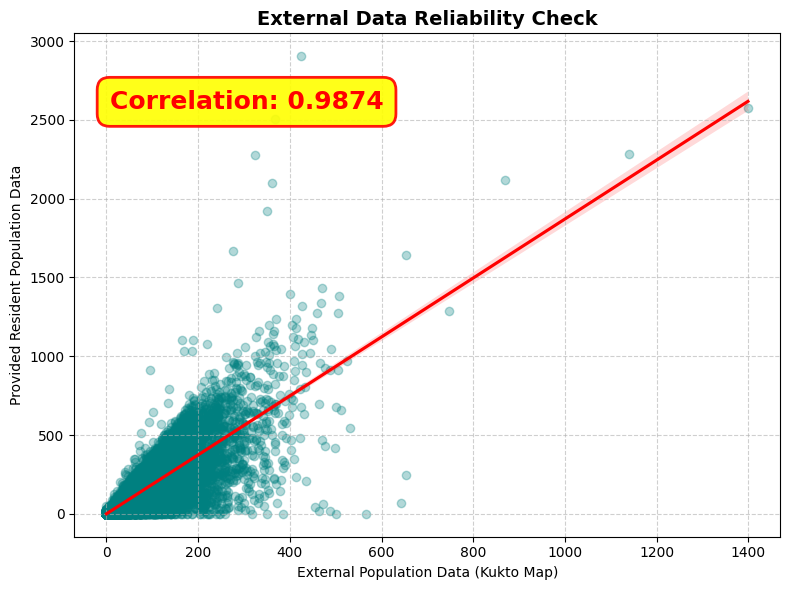

In [13]:
# 상관계수 비교 및 시각화

# 분석 요약
correlation = comparison_final['val'].corr(comparison_final['resident_senior_pop'])
total_rows = len(comparison_df)

display(Markdown(f"""
### 📊 데이터 비교 분석 요약
---
* **전체 분석 격자 수:** {total_rows:,}개
* **파일 이름:** `'total_resident.csv'`
* **상관계수:** `{correlation:.4f}`  \n두 데이터의 상관관계가 매우 높아, 외부 데이터를 활용한 어린이 거주인구 지표 확장의 타당성을 확보하였습니다.
---
"""))

# 주요 차이 발생 격자 확인 (Pandas Styling 적용)
print("🧐 [Top 10] 국토정보맵 vs 거주인구 데이터 차이가 큰 지역")

styled_df = (comparison_final[['lat', 'lon', 'val', 'resident_senior_pop', 'pop_diff', 'abs_diff']]
             .sort_values(by='abs_diff', ascending=False).head(10)
             .style.format('{:.2f}', subset=['lat', 'lon', 'pop_diff', 'abs_diff'])
             .background_gradient(cmap='Reds', subset=['abs_diff'])
             .set_properties(**{'text-align': 'center'})
            )

display(styled_df)
display(Markdown('---'))

# Correlation Plot
plt.figure(figsize=(8, 6))
sns.regplot(data=comparison_final, x='val', y='resident_senior_pop', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.title('External Data Reliability Check', fontsize=14, fontweight='bold')
plt.xlabel('External Population Data (Kukto Map)')
plt.ylabel('Provided Resident Population Data')

plt.annotate('Correlation: 0.9874', xy=(0.05, 0.85), xycoords='axes fraction', 
             fontsize=18, fontweight='extra bold', color='red', 
             bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="red", lw=2, alpha=0.9))       

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()